FIRST 5 ROWS
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0      

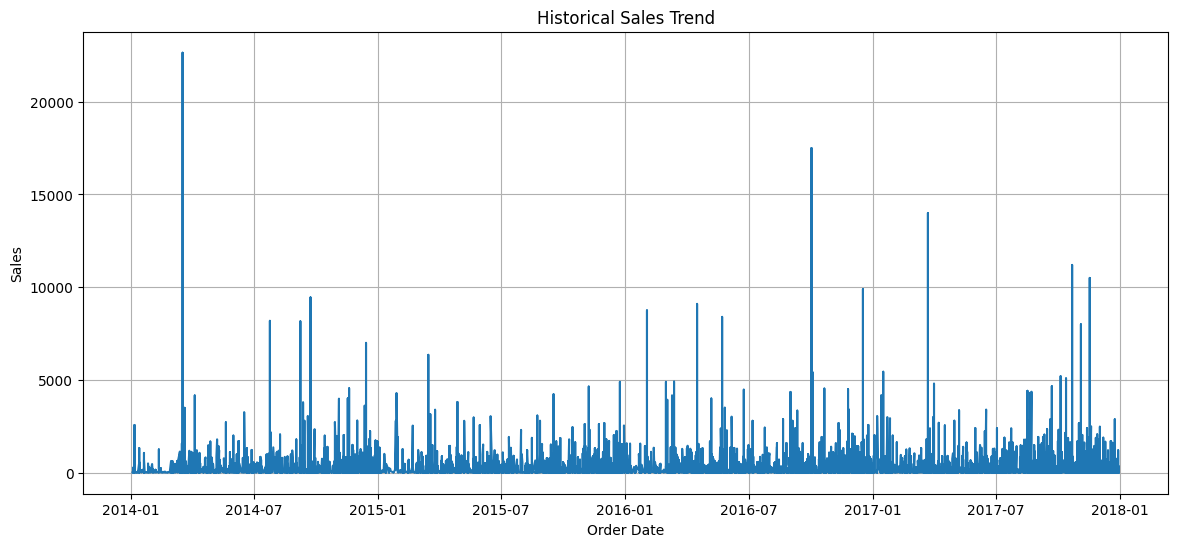

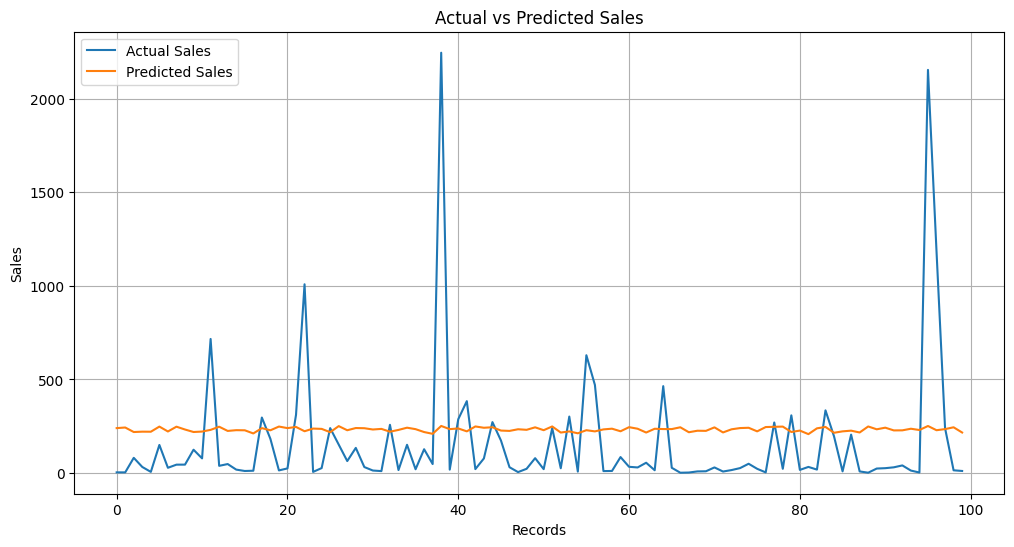


FUTURE SALES PREDICTIONS
   Year  Month  Day  DayOfWeek  WeekOfYear  IsWeekend  PredictedSales
0  2025      7    1          1          27          0      196.296001
1  2025      7    2          2          27          0      194.686516
2  2025      7    3          3          27          0      193.077031
3  2025      7    4          4          27          0      191.467546
4  2025      7    5          5          27          1      196.726337
5  2025      7    6          6          27          1      195.116852
6  2025      7    7          0          27          0      201.656199


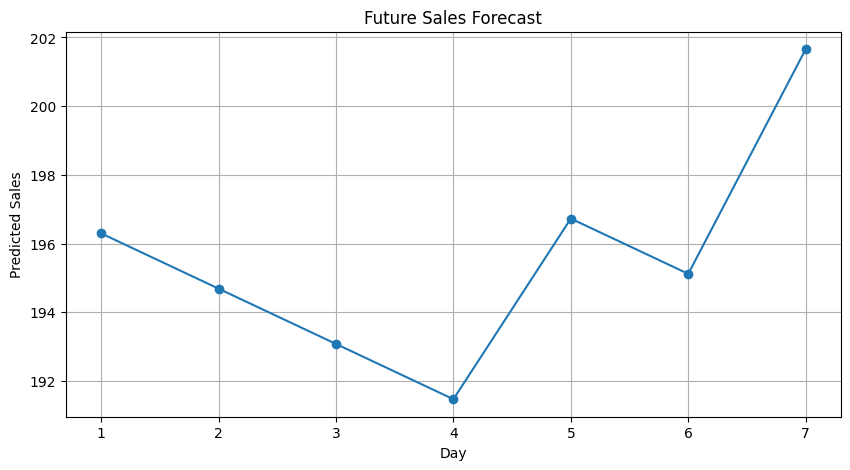


Predictions saved successfully!

BUSINESS INSIGHTS
---------------------------
1. Historical sales trends analyzed.
2. Linear Regression used for forecasting.
3. Weekend effect included as feature.
4. Future sales predicted successfully.
5. Results exported to CSV file.


In [34]:
# ==========================================================
# TASK-1 : SALES & DEMAND FORECASTING
# USING LINEAR REGRESSION
# DATASET: Sample - Superstore.csv
# ==========================================================

# INSTALL REQUIRED LIBRARIES
# pip install pandas numpy matplotlib scikit-learn

# ==========================================================
# 1. IMPORT LIBRARIES
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ==========================================================
# 2. LOAD DATASET
# ==========================================================

# YOUR FILE NAME
df = pd.read_csv("Sample - Superstore.csv", encoding='latin1')

# ==========================================================
# 3. DISPLAY DATA
# ==========================================================

print("FIRST 5 ROWS")
print(df.head())

print("\nCOLUMN NAMES")
print(df.columns)

print("\nDATA INFO")
print(df.info())

# ==========================================================
# 4. DATA CLEANING
# ==========================================================

# Remove missing values
df.dropna(inplace=True)

# Convert Order Date to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Sort by date
df = df.sort_values('Order Date')

# ==========================================================
# 5. FEATURE ENGINEERING
# ==========================================================

# Create new features from date

df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Day'] = df['Order Date'].dt.day
df['DayOfWeek'] = df['Order Date'].dt.dayofweek
df['WeekOfYear'] = df['Order Date'].dt.isocalendar().week

# Weekend feature
df['IsWeekend'] = df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

# ==========================================================
# 6. SELECT FEATURES AND TARGET
# ==========================================================

# Features
X = df[['Year', 'Month', 'Day', 'DayOfWeek', 'WeekOfYear', 'IsWeekend']]

# Target column
y = df['Sales']

# ==========================================================
# 7. TRAIN TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTRAINING DATA SIZE:", len(X_train))
print("TEST DATA SIZE:", len(X_test))

# ==========================================================
# 8. BUILD LINEAR REGRESSION MODEL
# ==========================================================

model = LinearRegression()

model.fit(X_train, y_train)

print("\nMODEL TRAINED SUCCESSFULLY")

# ==========================================================
# 9. MAKE PREDICTIONS
# ==========================================================

y_pred = model.predict(X_test)

# ==========================================================
# 10. MODEL EVALUATION
# ==========================================================

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("\nMODEL PERFORMANCE")
print("---------------------------")

print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

# ==========================================================
# 11. VISUALIZE HISTORICAL SALES
# ==========================================================

plt.figure(figsize=(14,6))

plt.plot(df['Order Date'], df['Sales'])

plt.title("Historical Sales Trend")
plt.xlabel("Order Date")
plt.ylabel("Sales")

plt.grid(True)

plt.show()

# ==========================================================
# 12. ACTUAL VS PREDICTED GRAPH
# ==========================================================

plt.figure(figsize=(12,6))

plt.plot(y_test.values[:100], label='Actual Sales')

plt.plot(y_pred[:100], label='Predicted Sales')

plt.title("Actual vs Predicted Sales")

plt.xlabel("Records")
plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

# ==========================================================
# 13. FUTURE SALES PREDICTION
# ==========================================================

future_data = pd.DataFrame({
    'Year': [2025]*7,
    'Month': [7]*7,
    'Day': [1,2,3,4,5,6,7],
    'DayOfWeek': [1,2,3,4,5,6,0],
    'WeekOfYear': [27]*7,
    'IsWeekend': [0,0,0,0,1,1,0]
})

future_predictions = model.predict(future_data)

future_data['PredictedSales'] = future_predictions

print("\nFUTURE SALES PREDICTIONS")
print(future_data)

# ==========================================================
# 14. FUTURE FORECAST VISUALIZATION
# ==========================================================

plt.figure(figsize=(10,5))

plt.plot(
    future_data['Day'],
    future_data['PredictedSales'],
    marker='o'
)

plt.title("Future Sales Forecast")

plt.xlabel("Day")
plt.ylabel("Predicted Sales")

plt.grid(True)

plt.show()

# ==========================================================
# 15. SAVE FUTURE PREDICTIONS
# ==========================================================

future_data.to_csv("future_sales_predictions.csv", index=False)

print("\nPredictions saved successfully!")

# ==========================================================
# 16. BUSINESS INSIGHTS
# ==========================================================

print("\nBUSINESS INSIGHTS")
print("---------------------------")

print("1. Historical sales trends analyzed.")

print("2. Linear Regression used for forecasting.")

print("3. Weekend effect included as feature.")

print("4. Future sales predicted successfully.")

print("5. Results exported to CSV file.")

# ==========================================================
# END OF PROJECT
# ==========================================================